# Analysis of Data Sources from PV

In [337]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import distance_matrix
import numpy as np
from scipy.stats import skew
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.dates as mdates
import os, sys

from pathlib import Path
from datetime import datetime, timedelta # Import datetime and timedelta

# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent

# Add the 'scripts' directory to sys.path to be able to import data_utils.py
sys.path.append(str(current_dir))


from capymoa.instance import Instance
from capymoa.stream import Schema

from scipy.stats import zscore
from scipy.signal import find_peaks
pd.set_option('display.max_colwidth', None)

import matplotlib.animation as animation
from scripts.model.OBKNN.model_OnlineBootKNN import median_of_means, transform_instance

In [338]:
# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent


FONTSIZE_MAIN = 11

FONTSIZE_SEC = 10

In [339]:
"""
NAME_FILE = "TNH_20260326_133415_ALPS"+".csv"
result = pd.read_csv(current_dir / "datasets" / "raw" / "ScenariosV5_Robustness" / NAME_FILE, sep=',', low_memory=False, dtype={'CURRENTTIMESTAMP': str})
"""
NAME_FILE = "SAR3_20251103_125605_ALPS"+".csv"
#result = pd.read_csv(current_dir / "datasets" / "raw" / "ScenariosV3_lite" / NAME_FILE, sep=',', low_memory=False, dtype={'CURRENTTIMESTAMP': str})
#result = pd.read_csv(current_dir / "datasets" / "raw" / "ScenariosV4_lite" / NAME_FILE, sep=',', low_memory=False, dtype={'CURRENTTIMESTAMP': str})
result = pd.read_csv(current_dir / "datasets" / "raw" / "ScenariosV5_GTV2" / NAME_FILE, sep=',', low_memory=False, dtype={'CURRENTTIMESTAMP': str})
#result = pd.read_csv(current_dir / "datasets" / "raw" / "ScenariosV5_Robustness" / NAME_FILE, sep=',', low_memory=False, dtype={'CURRENTTIMESTAMP': str})


In [340]:
result.columns[:]

Index(['CURRENTTIMESTAMP', '189.73', '190.12', '190.5', '190.88', '191.27',
       '191.65', '192.04', '192.42', '192.8',
       ...
       'ISCURRENTFAULT', 'ISSPECTROMETERFAULT', 'ISHVMODULEFAULT',
       'ISPOLLUTIONFAULT', 'ISALPSCONFIGERROR', 'ALPSSerial', 'DOWN',
       'DOWNMSG', 'SENSORPRESSURECHAMBER1', 'ANOMALY?'],
      dtype='object', length=2103)

In [341]:
result.columns[-1]

'ANOMALY?'

In [342]:
result['CURRENTTIMESTAMP'] = pd.to_datetime(result['CURRENTTIMESTAMP'])#.dt.tz_convert('UTC')



In [343]:
# 1. Create the Group ID (same as before)
result['group_id'] = (result['ANOMALY?'] != result['ANOMALY?'].shift()).cumsum()

# 2. Filter for anomalies
anomalies = result[result['ANOMALY?'] == 1]

# 3. Find the MAX date for each group (The time the anomaly stopped)
min_date_abnormal_case = anomalies.groupby('group_id')['CURRENTTIMESTAMP'].min().iloc[0]
max_date_abnormal_case = anomalies.groupby('group_id')['CURRENTTIMESTAMP'].max().iloc[0]

In [344]:
#min_date_abnormal_case = result[result['ANOMALY?']==1].CURRENTTIMESTAMP.min()
print("Min Date Abnormal:", min_date_abnormal_case)


Min Date Abnormal: 2025-11-03 13:30:00.541000+00:00


In [345]:
#max_date_abnormal_case = result[result['ANOMALY?']==1].CURRENTTIMESTAMP.max()
print("Max Date Abnormal:", max_date_abnormal_case)

Max Date Abnormal: 2025-11-03 13:39:59.412000+00:00


In [346]:
delta_window = 60 # by default 60

In [347]:
total_min_abnormal_case = min_date_abnormal_case - pd.Timedelta(delta_window, unit='s')
total_max_abnormal_case = max_date_abnormal_case + pd.Timedelta(delta_window, unit='s')

In [348]:

min_date_filter = result['CURRENTTIMESTAMP']>=total_min_abnormal_case
example_abnormal = result[min_date_filter]
print("Min Date (Filtered Abnormal):", example_abnormal.CURRENTTIMESTAMP.min())

Min Date (Filtered Abnormal): 2025-11-03 13:29:01.456000+00:00


In [349]:
max_date_filter = example_abnormal['CURRENTTIMESTAMP']<=total_max_abnormal_case
example_abnormal = example_abnormal[max_date_filter]
print("Max Date (Filtered Abnormal):", example_abnormal.CURRENTTIMESTAMP.max())

Max Date (Filtered Abnormal): 2025-11-03 13:40:58.487000+00:00


In [350]:
try:
    pressure_df = result[["PRESSURE","CURRENTTIMESTAMP"]]
    pressure_df.set_index('CURRENTTIMESTAMP', inplace=True)

    # --- 2. Identify the Peaks (Cycle Start Times) ---
    # Adjust 'height' and 'distance' based on your data characteristics.
    # Height filters out noise; distance ensures you count only one peak per cycle.
    peak_indices, _ = find_peaks(
        pressure_df["PRESSURE"],
        height=pressure_df["PRESSURE"].mean(), # e.g., only consider peaks above 0.0001 mBar
        distance=300 # Adjust this based on your sampling rate and cycle period
    )

    # Get the actual datetime values for the peaks
    peak_times = pressure_df.index[peak_indices]

    # --- 3. Calculate and Print the Mean Time Between Cycles ---
    if len(peak_times) < 2:
        print("Error: Fewer than two cycles were detected. Adjust the `height` or `distance` parameters.")
    else:
        # Calculate the time difference (period) between consecutive peaks
        cycle_periods = peak_times.to_series().diff().dropna()

        # Calculate the average period
        average_cycle_time = cycle_periods.mean()
        
        # Convert to seconds for a more convenient unit
        average_cycle_time_seconds = average_cycle_time.total_seconds()

        print(f"Number of cycles detected: {len(peak_times)}")
        print(f"\n Mean Time Between Cycles (Timedelta): {average_cycle_time}")
        print(f"   Mean Time Between Cycles (Seconds): {average_cycle_time_seconds:.2f} seconds")
except:
    print(f"No cycles ...")
    average_cycle_time_seconds = 0


Number of cycles detected: 2

 Mean Time Between Cycles (Timedelta): 0 days 00:09:48.847000
   Mean Time Between Cycles (Seconds): 588.85 seconds


In [351]:
stride_n_ab = average_cycle_time_seconds

In [352]:
min_date_filter = result['CURRENTTIMESTAMP']>= total_min_abnormal_case - pd.Timedelta(stride_n_ab, unit='s') 
example_normal_before = result[min_date_filter]
print("Min Date (Filtered Normal Before):", example_normal_before.CURRENTTIMESTAMP.min())

Min Date (Filtered Normal Before): 2025-11-03 13:19:12.609000+00:00


In [353]:
max_date_filter = example_normal_before['CURRENTTIMESTAMP']<=total_max_abnormal_case - pd.Timedelta(stride_n_ab, unit='s') 
example_normal_before = example_normal_before[max_date_filter] 
print("Max Date (Filtered Normal Before):", example_normal_before.CURRENTTIMESTAMP.max())

Max Date (Filtered Normal Before): 2025-11-03 13:31:09.640000+00:00


In [354]:
min_date_filter = result['CURRENTTIMESTAMP']>=total_min_abnormal_case + pd.Timedelta(stride_n_ab, unit='s') 
example_normal_after = result[min_date_filter]
print("Min Date (Filtered Normal After):", example_normal_after.CURRENTTIMESTAMP.min())

Min Date (Filtered Normal After): 2025-11-03 13:38:50.302000+00:00


In [355]:
max_date_filter = example_normal_after['CURRENTTIMESTAMP']<=total_max_abnormal_case + pd.Timedelta(stride_n_ab, unit='s') 
example_normal_after = example_normal_after[max_date_filter] 
print("Max Date (Filtered Normal After):", example_normal_after.CURRENTTIMESTAMP.max())

Max Date (Filtered Normal After): 2025-11-03 13:50:47.333000+00:00


In [356]:
print("Length Anomalies:",len(result[result["ANOMALY?"]==1]))

Length Anomalies: 600


In [357]:
print("Length Total:",len(result))

Length Total: 4200


## Analysing Datasets

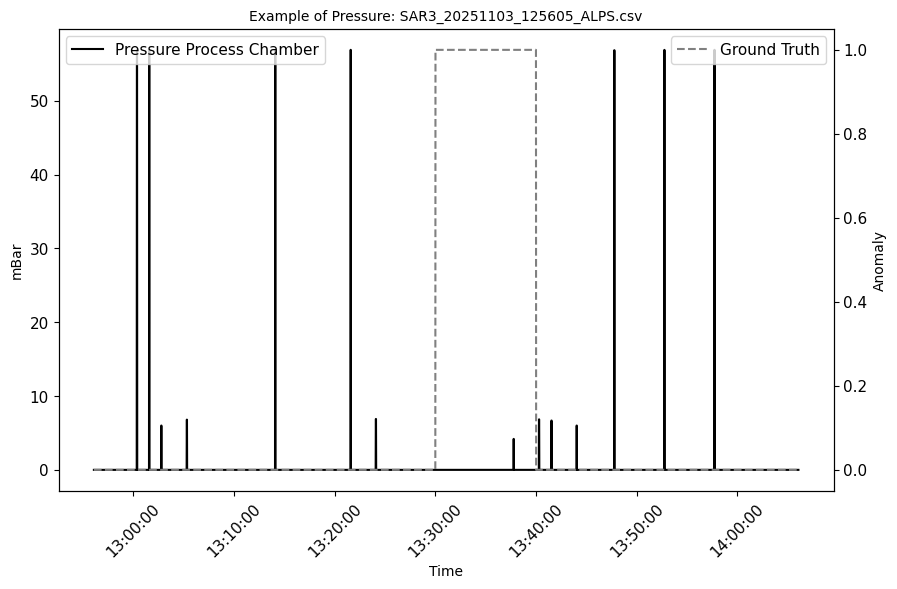

In [358]:
fig, ax1 = plt.subplots(figsize=(10, 6))


try:
    ax1.plot(result.CURRENTTIMESTAMP, result["SENSORPRESSURECHAMBER1"], color="black", label="Pressure Process Chamber")

    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('mBar', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Pressure: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

    
    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)
    try:
        # Second y-axis for Ground Truth
        ax2 = ax1.twinx()
        ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

        ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
        ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    
        
    except:
        print("No Ground Truth available")
    plt.show()
except:
    print("No Pressure Chamber available")



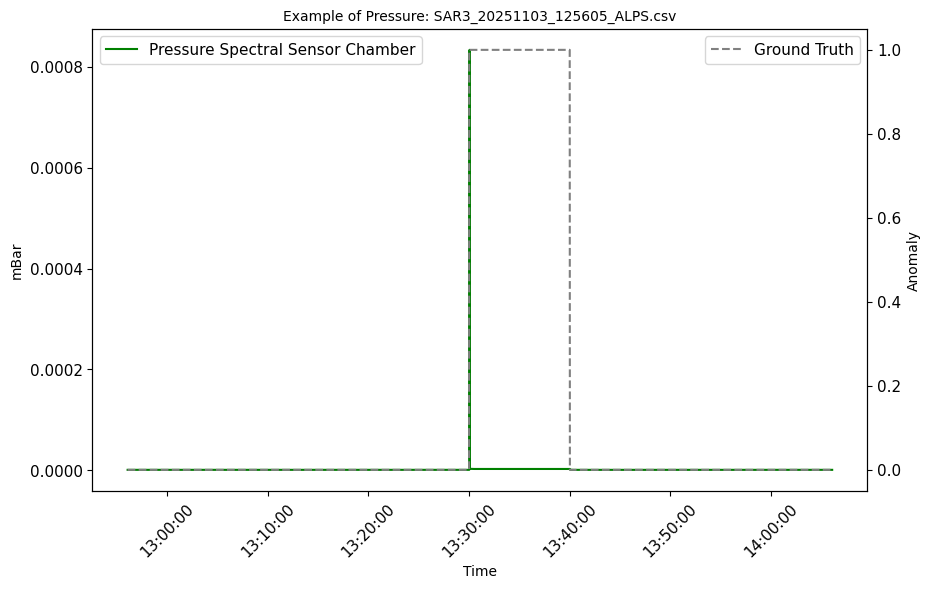

In [359]:
try:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(result.CURRENTTIMESTAMP, result["PRESSURE"], color="green", label="Pressure Spectral Sensor Chamber")

    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('mBar', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Pressure: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

    
    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    try:
        # Second y-axis for Ground Truth
        ax2 = ax1.twinx()
        ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

        ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
        ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    except Exception as e:
        print("No Ground Truth available", e)
    """
    try:
        # Second y-axis for Ground Truth
        ax2 = ax1.twinx()
        ax2.plot(result.CURRENTTIMESTAMP, result["ETATREALTIMELIFE"], color="Grey", linestyle="dashed", label="ETATREALTIMELIFE")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

        ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
        ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    except:
        print("No ETATREALTIMELIFE available")
    """
    plt.show()
except:
    print("No Pressure Chamber available")

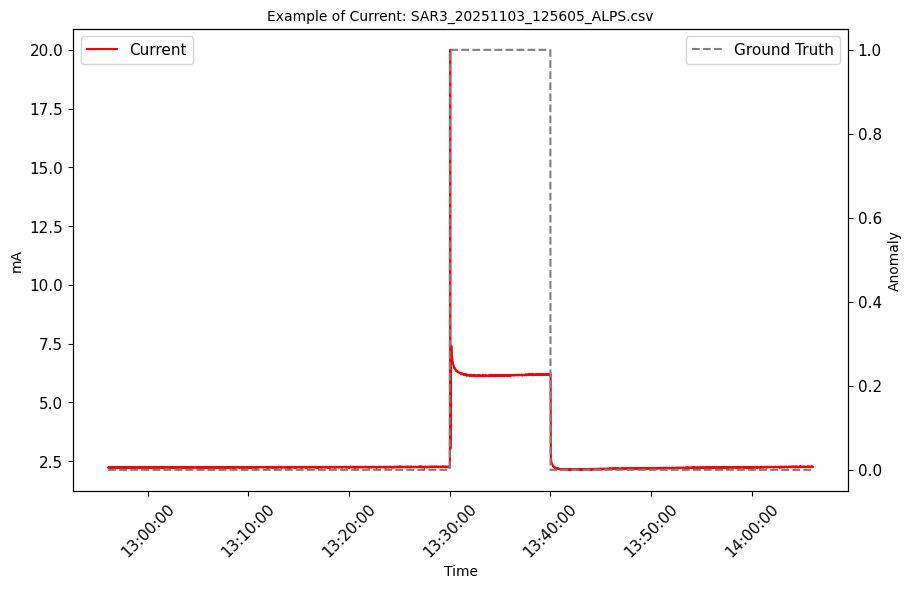

In [360]:
try:
    fig, ax1 = plt.subplots(figsize=(10, 6))


    ax1.plot(result.CURRENTTIMESTAMP, result["CURRENT"], color="red", label="Current")


    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('mA', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Current: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    try:
        # Second y-axis for Ground Truth
        ax2 = ax1.twinx()
        ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

        ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
        ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    except:
        print("No Ground Truth available")


        
    plt.show()
except:
    print("No Current Information available")

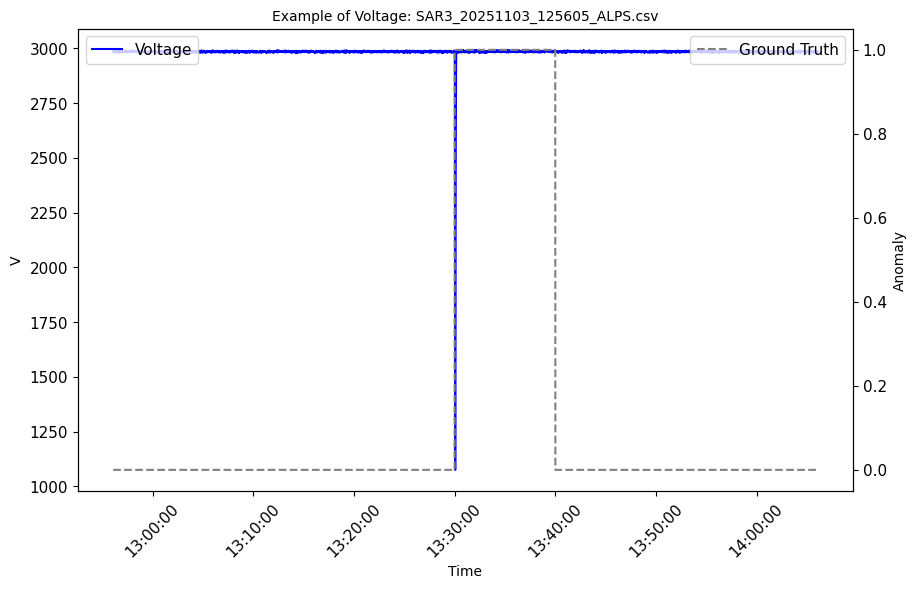

In [361]:
try:    
    fig, ax1 = plt.subplots(figsize=(10, 6))

    #ax1.plot(result.CURRENTTIMESTAMP, result["PRESSURE"], color="green", label="Pressure")
    #ax1.plot(result.CURRENTTIMESTAMP, result["CURRENT"], color="red", label="Current")
    ax1.plot(result.CURRENTTIMESTAMP, result["VOLTAGE"], color="blue", label="Voltage")

    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('V', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Voltage: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    try:
        # Second y-axis for Ground Truth
        ax2 = ax1.twinx()
        ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

        ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
        ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    except:
        print("No Ground Truth available")



    plt.show()
except:
    print("No Voltage Information available")

### Spectrograms in Time

In [362]:
MAX_POS_SPECTRA = 2048
MIN_POS_SPECTRA = 1

/tmp/ipykernel_371717/1450819928.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)


No ETATREALTIMELIFE available


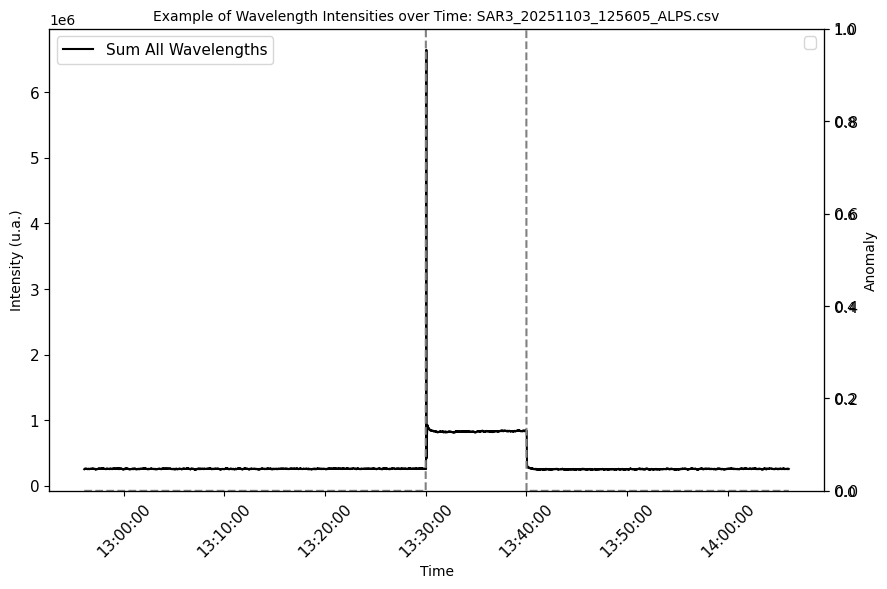

In [363]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].sum(axis=1), color="black", label="Sum All Wavelengths")


ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of Wavelength Intensities over Time: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.set_ylim(0,1)
except:
    print("No Ground Truth available")


try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["ETATREALTIMELIFE"], color="Grey", linestyle="dashed", label="ETATREALTIMELIFE")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
except:
    print("No ETATREALTIMELIFE available")
    
plt.show()




/tmp/ipykernel_371717/842620210.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)


No ETATREALTIMELIFE available


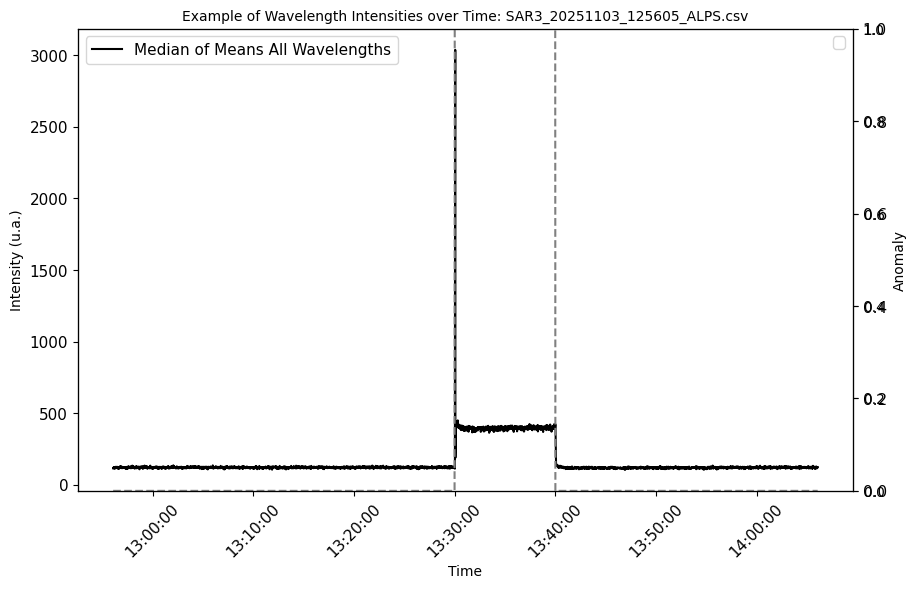

In [364]:
fig, ax1 = plt.subplots(figsize=(10, 6))
#ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].mean(axis=1), color="green", label="Mean All Wavelengths")
ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].apply(
    lambda row: median_of_means(row), 
    axis=1
), color="black", label="Median of Means All Wavelengths")

#ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].max(axis=1), color="red", label="Max All Wavelengths")
#ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].min(axis=1), color="blue", label="Min All Wavelengths")

ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of Wavelength Intensities over Time: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.set_ylim(0,1)
except:
    print("No Ground Truth available")


try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["ETATREALTIMELIFE"], color="Grey", linestyle="dashed", label="ETATREALTIMELIFE")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
except:
    print("No ETATREALTIMELIFE available")
    
plt.show()




In [365]:
"""
from aeon.anomaly_detection.series.distance_based import LeftSTAMPi
from scripts.data_utils import calculate_performance_metrics

X = result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].max(axis=1)
detector = LeftSTAMPi(window_size=30, n_init_train=600)
result["score_leftstampi"] = detector.fit_predict(X) 
 
roc_auc, pr_auc, max_f1, metrics = calculate_performance_metrics(result, "ANOMALY?","score_leftstampi")
pr_auc
"""

'\nfrom aeon.anomaly_detection.series.distance_based import LeftSTAMPi\nfrom scripts.data_utils import calculate_performance_metrics\n\nX = result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].max(axis=1)\ndetector = LeftSTAMPi(window_size=30, n_init_train=600)\nresult["score_leftstampi"] = detector.fit_predict(X) \n \nroc_auc, pr_auc, max_f1, metrics = calculate_performance_metrics(result, "ANOMALY?","score_leftstampi")\npr_auc\n'

In [366]:
"""
from aeon.anomaly_detection.series.distance_based import MERLIN
X = result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].max(axis=1)
detector = MERLIN(min_length=4, max_length=5)
result["score_merlin"] = detector.fit_predict(X) 
result["score_merlin"] = result["score_merlin"].replace(True, 1).replace(False, 0)

roc_auc, pr_auc, max_f1, metrics = calculate_performance_metrics(result, "ANOMALY?","score_merlin")
pr_auc
"""

'\nfrom aeon.anomaly_detection.series.distance_based import MERLIN\nX = result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].max(axis=1)\ndetector = MERLIN(min_length=4, max_length=5)\nresult["score_merlin"] = detector.fit_predict(X) \nresult["score_merlin"] = result["score_merlin"].replace(True, 1).replace(False, 0)\n\nroc_auc, pr_auc, max_f1, metrics = calculate_performance_metrics(result, "ANOMALY?","score_merlin")\npr_auc\n'

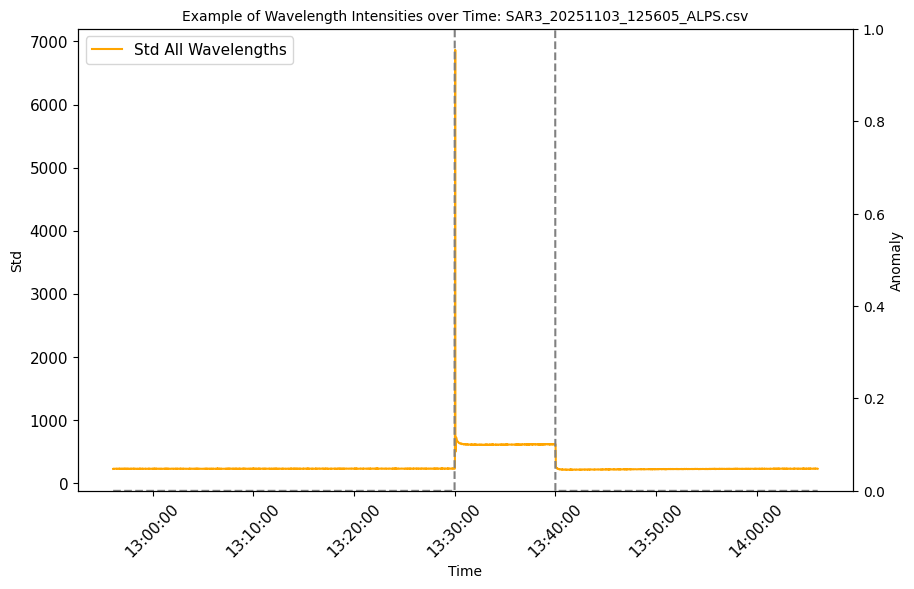

In [367]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].std(axis=1), color="Orange", label="Std All Wavelengths")
ax1.legend(loc='upper right', fontsize=FONTSIZE_MAIN)
ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Std', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of Wavelength Intensities over Time: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.set_ylim(0,1)

except:
    print("No Ground Truth available")



plt.show()




In [368]:
cols_slice = result.columns[MIN_POS_SPECTRA:MAX_POS_SPECTRA]

# Convert the slice to float *once* for efficiency
cols_as_float = cols_slice.astype(float)


In [369]:
# Nitrogen (RS1)
# Create the mask using & (bitwise AND) and parentheses
mask = (cols_as_float > 380.22) & (cols_as_float <= 400.20)
# Now apply the mask
filtered_column_names = cols_slice[mask]
n_wavelength = filtered_column_names[int(len(filtered_column_names)/2)]
n_color = "indigo" 
print(n_wavelength)

390.17


In [370]:
# Oxigen (RS2)
# Create the mask using & (bitwise AND) and parentheses
mask = (cols_as_float > 767.01) & (cols_as_float <= 787.02)
# Now apply the mask
filtered_column_names = cols_slice[mask]
o_wavelength = filtered_column_names[int(len(filtered_column_names)/2)]
o_color = "maroon"
print(o_wavelength)

777.05


In [371]:
# Argon (RS3)
# Create the mask using & (bitwise AND) and parentheses
mask = (cols_as_float > 748.06) & (cols_as_float <= 752.50)
# Now apply the mask
filtered_column_names = cols_slice[mask]
a_wavelength = filtered_column_names[int(len(filtered_column_names)/2)]
a_color = "firebrick"
print(a_wavelength)

750.5


In [372]:
# OH (RS4)
# Create the mask using & (bitwise AND) and parentheses
mask = (cols_as_float > 302.18) & (cols_as_float <= 310.30)
# Now apply the mask
filtered_column_names = cols_slice[mask]
oh_wavelength = filtered_column_names[int(len(filtered_column_names)/2)]
oh_color = "darkorange"
print(oh_wavelength)

306.54


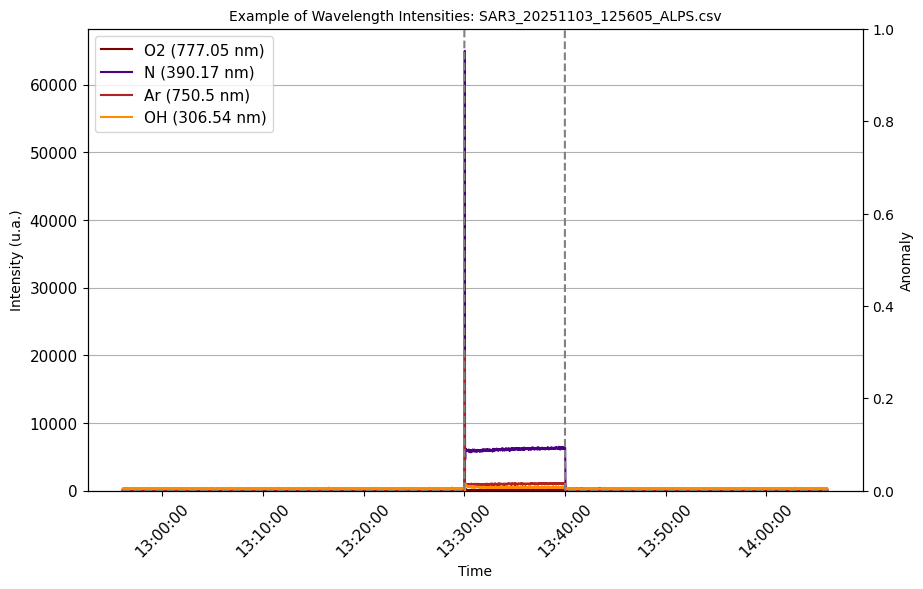

In [373]:
try:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot 'O2' for Wavelength: 
    ax1.plot(result.CURRENTTIMESTAMP, result[o_wavelength], color=o_color, label=f"O2 ({o_wavelength} nm)")
    
    # Plot 'N' for Wavelength: 
    ax1.plot(result.CURRENTTIMESTAMP, result[n_wavelength], color=n_color, label=f"N ({n_wavelength} nm)")

    # Plot 'Ar' for Wavelength: 
    ax1.plot(result.CURRENTTIMESTAMP, result[a_wavelength], color=a_color, label=f"Ar ({a_wavelength} nm)")

    # Plot 'OH' for Wavelength: 
    ax1.plot(result.CURRENTTIMESTAMP, result[oh_wavelength], color=oh_color, label=f"OH ({oh_wavelength} nm)")



    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Wavelength Intensities: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax1.grid(axis='y')
    
    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)
    ax1.set_ylim(0, )
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    try:

        ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        ax2.set_ylim(0,1)
    except:
        print("No Ground Truth available")

    
    """
    try:
        # Second y-axis for Ground Truth
        ax2 = ax1.twinx()
        #ax2.plot(result.CURRENTTIMESTAMP, result["ETATREALTIMELIFE"], color="Grey", linestyle="dashed", label="ETATREALTIMELIFE")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

        ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
        ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    except:
        print("No ETATREALTIMELIFE available")
    
    plt.show()
    """

except Exception as e:
    print("Error plotting specific wavelengths", e)


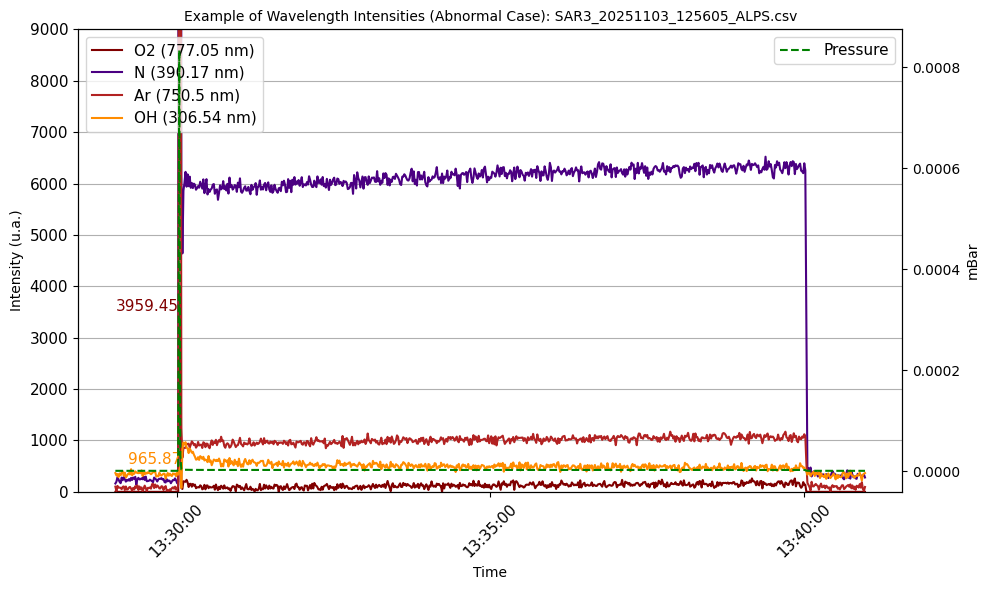

In [374]:


# --- The Plotting Code with Maximum Value Text (No Arrows, Text Bottom-Left) ---

try:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Plotting Wavelengths ---
    
    # 1. Plot 'O2'
    ax1.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal[o_wavelength], color=o_color, label=f"O2 ({o_wavelength} nm)")
    
    # 2. Plot 'N'
    ax1.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal[n_wavelength], color=n_color, label=f"N ({n_wavelength} nm)")

    # 3. Plot 'Ar'
    ax1.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal[a_wavelength], color=a_color, label=f"Ar ({a_wavelength} nm)")

    # 4. Plot 'OH'
    ax1.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal[oh_wavelength], color=oh_color, label=f"OH ({oh_wavelength} nm)")

    # --- Function to Annotate Max Value (No Arrows, Text Bottom-Left) ---
    def annotate_max_bottom_left(dataframe, column, color, y_offset_factor=0.95, x_offset_seconds=2):
        """Calculates and annotates only the maximum intensity value, positioned at the 
        bottom-left of the peak and without an arrow."""
        
        # 1. Find max intensity value
        max_intensity = dataframe[column].max()
        
        # 2. Find the index of the max intensity
        max_idx = dataframe[column].idxmax()
        
        # 3. Get the corresponding timestamp (x-coordinate)
        max_time = dataframe.loc[max_idx, 'CURRENTTIMESTAMP']
        
        # 4. Create the text: just the formatted number
        annotation_text = f"{max_intensity:.2f}" 

        # 5. Annotate the point (no arrowprops)
        ax1.annotate(
            annotation_text, 
            xy=(max_time, max_intensity), # Anchor point
            # Position the text left and down
            xytext=(max_time - pd.Timedelta(seconds=x_offset_seconds), max_intensity * y_offset_factor), 
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='right', # Horizontal alignment: text flows to the left from the xytext point
            va='top'    # Vertical alignment: text flows down from the xytext point (ensures it's below the peak)
        )

    # --- Applying Annotations for all lines (Text Bottom-Left, No Arrows) ---
    # Adjust offsets for best visual separation
    annotate_max_bottom_left(example_abnormal, o_wavelength, o_color, y_offset_factor=0.95, x_offset_seconds=1)
    annotate_max_bottom_left(example_abnormal, n_wavelength, n_color, y_offset_factor=0.90, x_offset_seconds=2)
    annotate_max_bottom_left(example_abnormal, a_wavelength, a_color, y_offset_factor=0.85, x_offset_seconds=3)
    annotate_max_bottom_left(example_abnormal, oh_wavelength, oh_color, y_offset_factor=0.80, x_offset_seconds=4)
    
    # --- Axis and Title Setup ---
    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Wavelength Intensities (Abnormal Case): ' + NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax1.grid(axis='y')
    ax1.set_ylim(0, 9000)
    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    # --- Second Y-axis for Ground Truth ---
    ax2 = ax1.twinx()
    try:
        #ax2.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        #ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        #ax2.set_ylim(0, 1)
        ax2.plot(example_abnormal.CURRENTTIMESTAMP, example_abnormal["PRESSURE"], linestyle="dashed", color="green", label="Pressure")
        ax2.set_ylabel('mBar', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)
    except:
        print("No info. available")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Error plotting specific wavelengths", e)

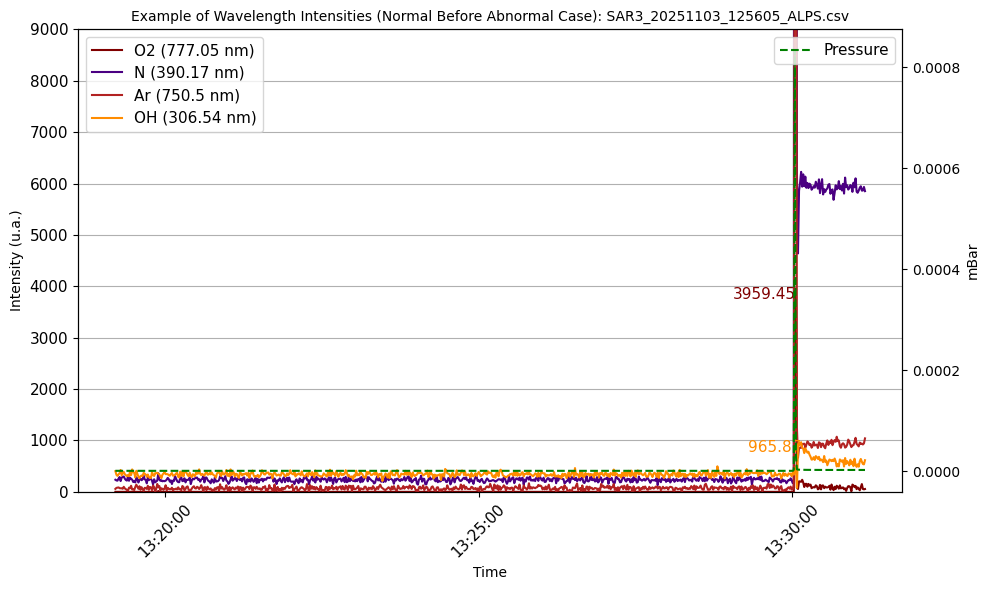

In [375]:

# --- The Plotting Code with Maximum Value Text (No Arrows, Text Below Peak) ---

try:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Plotting Wavelengths ---
    
    # 1. Plot 'O2'
    ax1.plot(example_normal_before.CURRENTTIMESTAMP, example_normal_before[o_wavelength], color=o_color, label=f"O2 ({o_wavelength} nm)")
    
    # 2. Plot 'N'
    ax1.plot(example_normal_before.CURRENTTIMESTAMP, example_normal_before[n_wavelength], color=n_color, label=f"N ({n_wavelength} nm)")

    # 3. Plot 'Ar'
    ax1.plot(example_normal_before.CURRENTTIMESTAMP, example_normal_before[a_wavelength], color=a_color, label=f"Ar ({a_wavelength} nm)")

    # 4. Plot 'OH'
    ax1.plot(example_normal_before.CURRENTTIMESTAMP, example_normal_before[oh_wavelength], color=oh_color, label=f"OH ({oh_wavelength} nm)")

    # --- Function to Annotate Max Value (No Arrows, Text Below Peak) ---
    def annotate_max_bottom(dataframe, column, color, y_offset_factor=0.95):
        """Calculates and annotates only the maximum intensity value, positioned 
        directly below the peak and without an arrow."""
        
        # 1. Find max intensity value
        max_intensity = dataframe[column].max()
        
        # 2. Find the index of the max intensity
        max_idx = dataframe[column].idxmax()
        
        # 3. Get the corresponding timestamp (x-coordinate)
        max_time = dataframe.loc[max_idx, 'CURRENTTIMESTAMP']
        
        # 4. Create the text: just the formatted number
        annotation_text = f"{max_intensity:.2f}" 

        # 5. Annotate the point (no arrowprops, ha='center', y_offset_factor < 1.0)
        ax1.annotate(
            annotation_text, 
            xy=(max_time, max_intensity), # Anchor point
            # Position the text at the same x-coordinate but slightly below the max point
            xytext=(max_time, max_intensity * y_offset_factor), 
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='right' # Center the text over the max point
        )

    # --- Applying Annotations for all lines (Text Below Peak, No Arrows) ---
    # Adjust y_offset_factor (must be < 1.0) for best visual placement
    annotate_max_bottom(example_normal_before, o_wavelength, o_color, y_offset_factor=0.95)
    annotate_max_bottom(example_normal_before, n_wavelength, n_color, y_offset_factor=0.90)
    annotate_max_bottom(example_normal_before, a_wavelength, a_color, y_offset_factor=0.85)
    annotate_max_bottom(example_normal_before, oh_wavelength, oh_color, y_offset_factor=0.80)
    
    # --- Axis and Title Setup ---
    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Wavelength Intensities (Normal Before Abnormal Case): ' + NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax1.grid(axis='y')
    ax1.set_ylim(0, 9000)
    
    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    # --- Second Y-axis for Ground Truth ---
    ax2 = ax1.twinx()
    try:
        #ax2.plot(example_normal_before.CURRENTTIMESTAMP, example_normal_before["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        #ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        #ax2.set_ylim(0, 1)
        ax2.plot(example_normal_before.CURRENTTIMESTAMP, example_normal_before["PRESSURE"], linestyle="dashed", color="green", label="Pressure")
        ax2.set_ylabel('mBar', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)
    except:
        print("No info. available")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Error plotting specific wavelengths", e)

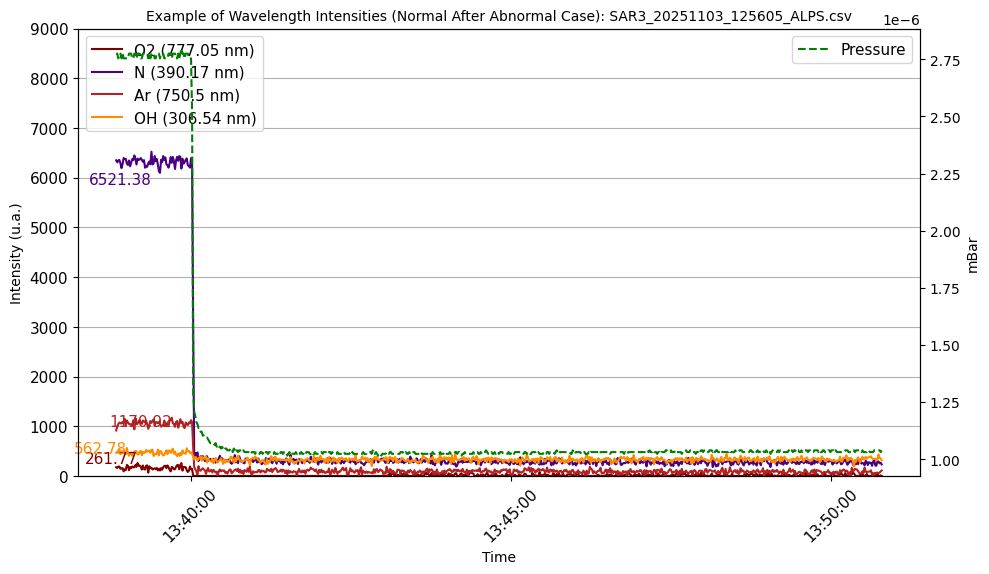

In [376]:

# --- The Plotting Code with Maximum Value Text (No Arrows, Text Below Peak) ---

try:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Plotting Wavelengths ---
    
    # 1. Plot 'O2'
    ax1.plot(example_normal_after.CURRENTTIMESTAMP, example_normal_after[o_wavelength], color=o_color, label=f"O2 ({o_wavelength} nm)")
    
    # 2. Plot 'N'
    ax1.plot(example_normal_after.CURRENTTIMESTAMP, example_normal_after[n_wavelength], color=n_color, label=f"N ({n_wavelength} nm)")

    # 3. Plot 'Ar'
    ax1.plot(example_normal_after.CURRENTTIMESTAMP, example_normal_after[a_wavelength], color=a_color, label=f"Ar ({a_wavelength} nm)")

    # 4. Plot 'OH'
    ax1.plot(example_normal_after.CURRENTTIMESTAMP, example_normal_after[oh_wavelength], color=oh_color, label=f"OH ({oh_wavelength} nm)")

    # --- Function to Annotate Max Value (No Arrows, Text Below Peak) ---
    def annotate_max_bottom(dataframe, column, color, y_offset_factor=0.95):
        """Calculates and annotates only the maximum intensity value, positioned 
        directly below the peak and without an arrow."""
        
        # 1. Find max intensity value
        max_intensity = dataframe[column].max()
        
        # 2. Find the index of the max intensity
        max_idx = dataframe[column].idxmax()
        
        # 3. Get the corresponding timestamp (x-coordinate)
        max_time = dataframe.loc[max_idx, 'CURRENTTIMESTAMP']
        
        # 4. Create the text: just the formatted number
        annotation_text = f"{max_intensity:.2f}" 

        # 5. Annotate the point (no arrowprops, ha='center', y_offset_factor < 1.0)
        ax1.annotate(
            annotation_text, 
            xy=(max_time, max_intensity), # Anchor point
            # Position the text at the same x-coordinate but slightly below the max point
            xytext=(max_time, max_intensity * y_offset_factor), 
            fontsize=FONTSIZE_MAIN,
            color=color,
            ha='right' # Center the text over the max point
        )

    # --- Applying Annotations for all lines (Text Below Peak, No Arrows) ---
    # Adjust y_offset_factor (must be < 1.0) for best visual placement
    annotate_max_bottom(example_normal_after, o_wavelength, o_color, y_offset_factor=0.95)
    annotate_max_bottom(example_normal_after, n_wavelength, n_color, y_offset_factor=0.90)
    annotate_max_bottom(example_normal_after, a_wavelength, a_color, y_offset_factor=0.85)
    annotate_max_bottom(example_normal_after, oh_wavelength, oh_color, y_offset_factor=0.80)
    
    # --- Axis and Title Setup ---
    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Wavelength Intensities (Normal After Abnormal Case): ' + NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax1.grid(axis='y')
    ax1.set_ylim(0, 9000)

    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    # --- Second Y-axis for Ground Truth ---
    ax2 = ax1.twinx()
    try:
        #ax2.plot(example_normal_after.CURRENTTIMESTAMP, example_normal_after["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        #ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        #ax2.set_ylim(0, 1)
        ax2.plot(example_normal_after.CURRENTTIMESTAMP, example_normal_after["PRESSURE"], linestyle="dashed", color="green", label="Pressure")
        ax2.set_ylabel('mBar', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)
    except:
        print("No info. available")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Error plotting specific wavelengths", e)

### Example of Spectral Data

/tmp/ipykernel_371717/2054335979.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', fontsize=12, frameon=True)


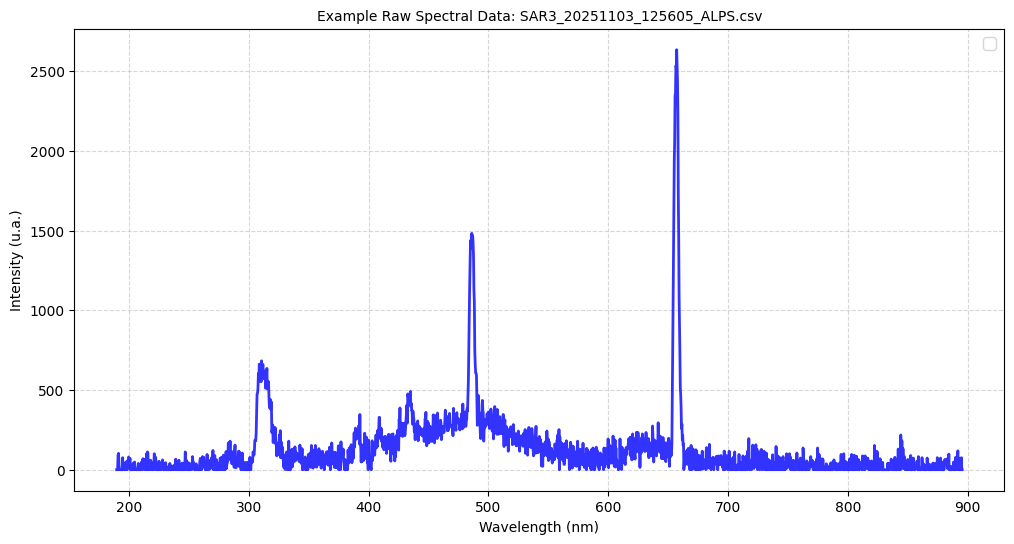

In [377]:
max_pressure_idx = 10
index_instance = max_pressure_idx + 1
fig, ax1 = plt.subplots(figsize=(12, 6))  # Slightly wider for better visibility

# Convert wavelength columns to float and sort
wavelengths = result.columns[MIN_POS_SPECTRA:MAX_POS_SPECTRA].astype(float)
intensities = result.iloc[index_instance, MIN_POS_SPECTRA:MAX_POS_SPECTRA]

# Plot with enhancements
ax1.plot(wavelengths, intensities, color="blue", linewidth=2, alpha=0.8)

# Labels & Title
ax1.set_xlabel('Wavelength (nm)', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
ax1.set_title(f'Example Raw Spectral Data: {NAME_FILE}', fontsize=FONTSIZE_SEC)

# Grid for better readability
ax1.grid(True, linestyle="--", alpha=0.5)

# Legend
ax1.legend(loc='upper right', fontsize=12, frameon=True)

plt.show()


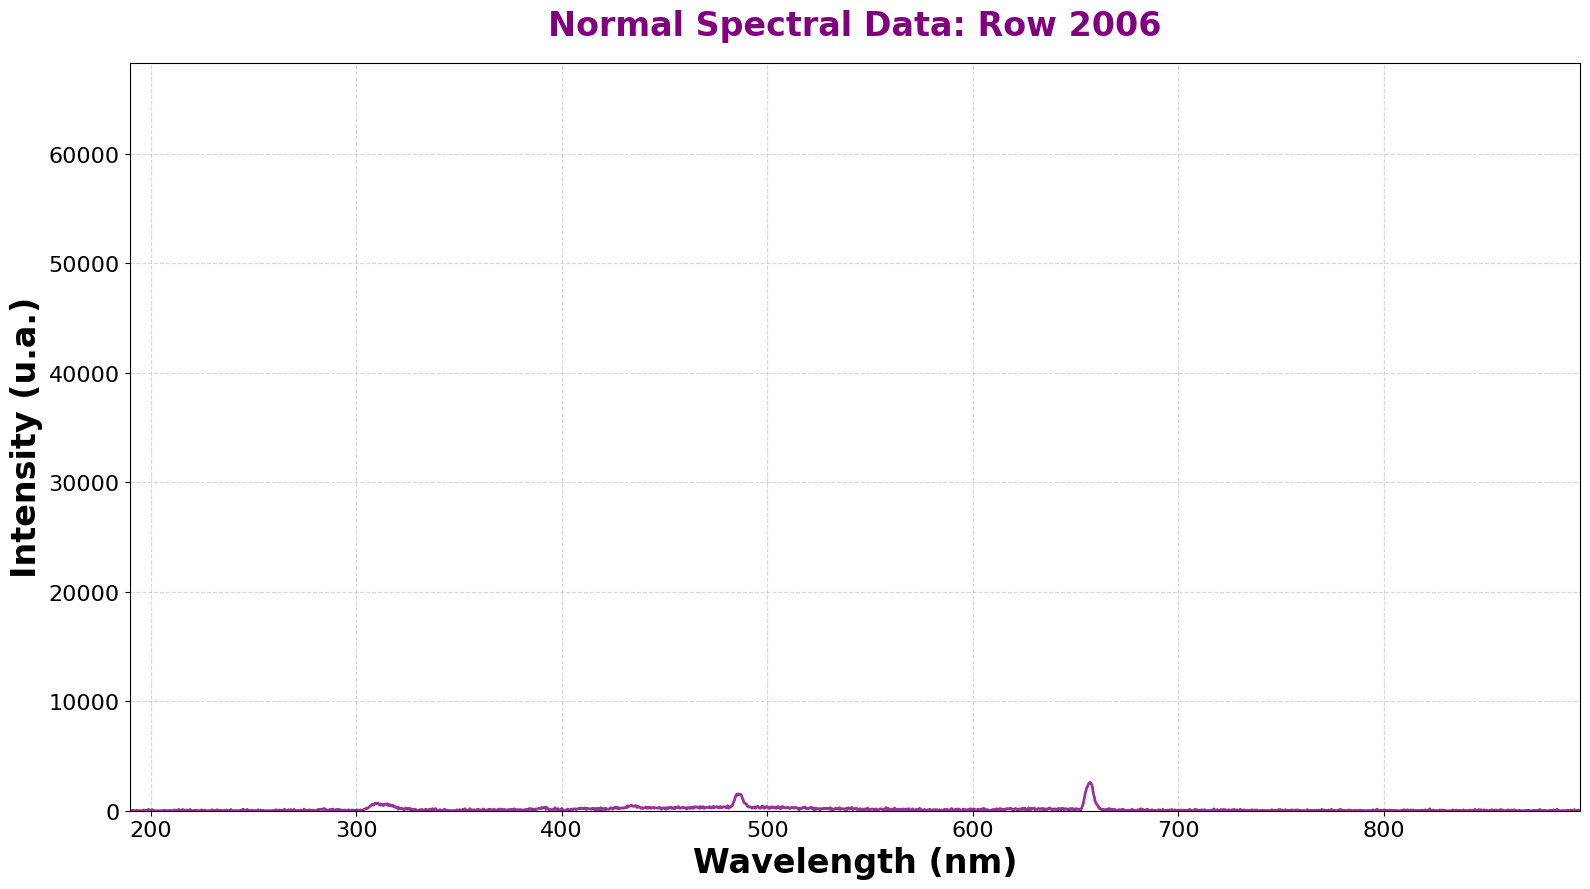

In [378]:

min_annormal = result[ result["ANOMALY?"]==1].index.min()
start_index = min_annormal-30
end_index = min_annormal+150
indices = range(start_index, end_index)

fig, ax1 = plt.subplots(figsize=(16, 9))
wavelengths = result.columns[MIN_POS_SPECTRA:MAX_POS_SPECTRA].astype(float)

# Create an empty line object that we will update in the loop
line, = ax1.plot([], [], color="purple", linewidth=2, alpha=0.8)

# Make labels bold and significantly larger (replace FONTSIZE_SEC with explicit numbers)
ax1.set_xlabel('Wavelength (nm)', fontsize=24, fontweight='bold')
ax1.set_ylabel('Intensity (u.a.)', fontsize=24, fontweight='bold')
ax1.grid(True, linestyle="--", alpha=0.5)

# Make the numbers on the X and Y axes bigger
ax1.tick_params(axis='both', labelsize=16)

# IMPORTANT: Fix your axis limits so the GIF doesn't jump around
ax1.set_xlim(wavelengths.min(), wavelengths.max())
ax1.set_ylim(0, result.iloc[start_index:end_index, MIN_POS_SPECTRA:MAX_POS_SPECTRA].max().max() * 1.05)

# Make title massive, bold, and add padding (pad=20) so it doesn't overlap the chart
title_obj = ax1.set_title("Abnormal Spectral Data: Row 99999", fontsize=24, fontweight='bold', pad=20)
fig.tight_layout()

def update(frame_index):
    intensities = result.iloc[frame_index, MIN_POS_SPECTRA:MAX_POS_SPECTRA]
    is_anomaly = result["ANOMALY?"].iloc[frame_index] 
    
    # Switch color and label based on status
    color = "red" if is_anomaly else "purple"
    status = "Abnormal" if is_anomaly else "Normal"
    
    line.set_data(wavelengths, intensities)
    line.set_color(color)
    #title_obj.set_text(f'{status} Spectral Data')
    title_obj.set_text(f'{status} Spectral Data: Row {frame_index}')
    title_obj.set_color(color)
    
    # Return both line and title so they update correctly
    return line, title_obj


ani = animation.FuncAnimation(fig, update, frames=indices, blit=True)
#ani.save(r'img_anomalies\gif_spectral_data.gif', writer='pillow', fps=60, dpi=150) # fps controls the speed



### Example of Z-Normalised Spectral Data

In [379]:
schema = Schema.from_custom(feature_names=result.columns[MIN_POS_SPECTRA:MAX_POS_SPECTRA])
instance = Instance.from_array(schema, np.array(intensities, dtype=np.float64))


/tmp/ipykernel_371717/1926309089.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', fontsize=12, frameon=True)


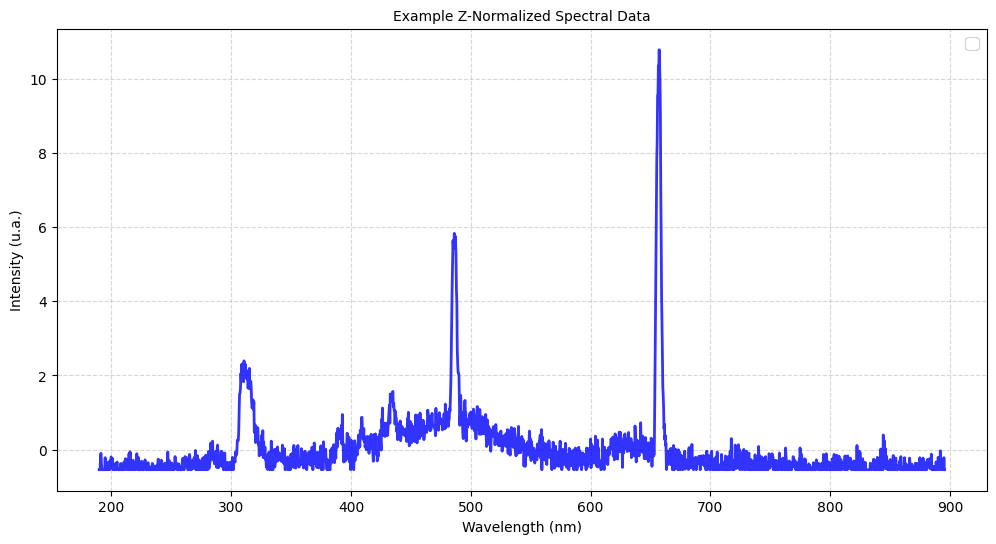

In [380]:
### Example of Z-Normalised Spectral Data
instance_t = transform_instance(instance, transf="ZNORM")

fig, ax1 = plt.subplots(figsize=(12, 6))  # Slightly wider for better visibility

# Plot with enhancements
ax1.plot(wavelengths, instance_t.x, color="blue", linewidth=2, alpha=0.8)

# Labels & Title
ax1.set_xlabel('Wavelength (nm)', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
ax1.set_title(f'Example Z-Normalized Spectral Data', fontsize=FONTSIZE_SEC)

# Grid for better readability
ax1.grid(True, linestyle="--", alpha=0.5)

# Legend
ax1.legend(loc='upper right', fontsize=12, frameon=True)

plt.show()

### Example of Normalized Spectral Data In Time

In [381]:
result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA] = zscore(result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA], axis=1)

/tmp/ipykernel_371717/1450819928.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)


No ETATREALTIMELIFE available


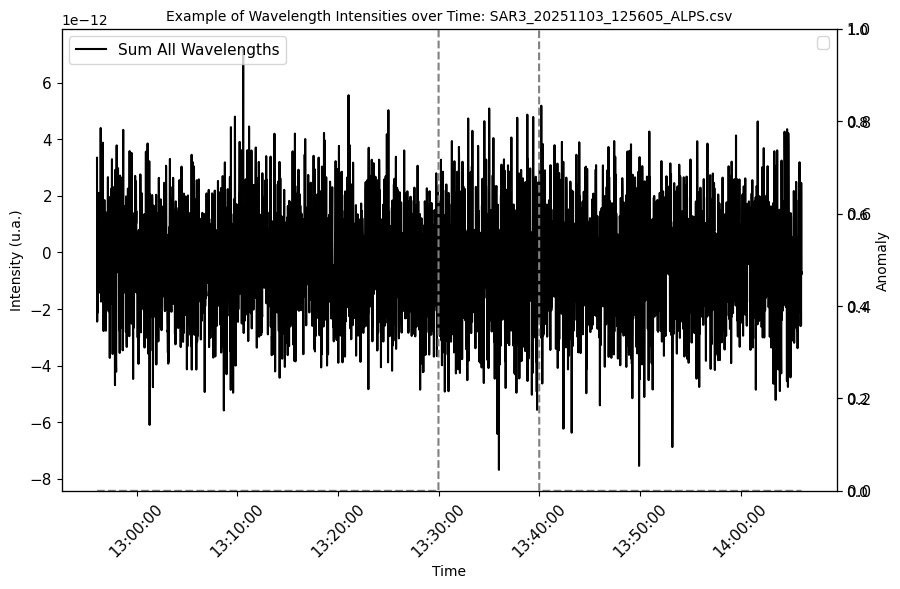

In [382]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].sum(axis=1), color="black", label="Sum All Wavelengths")


ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of Wavelength Intensities over Time: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.set_ylim(0,1)
except:
    print("No Ground Truth available")


try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["ETATREALTIMELIFE"], color="Grey", linestyle="dashed", label="ETATREALTIMELIFE")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
except:
    print("No ETATREALTIMELIFE available")
    
plt.show()




/tmp/ipykernel_371717/1892221814.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)


No ETATREALTIMELIFE available


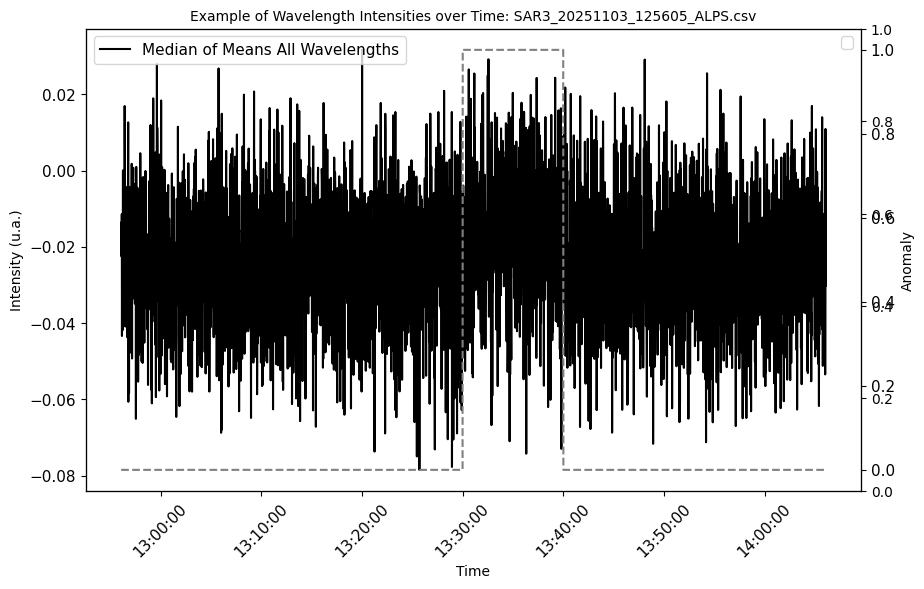

In [383]:
fig, ax1 = plt.subplots(figsize=(10, 6))

#ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].mean(axis=1), color="green", label="Mean All Wavelengths")
ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].apply(
    lambda row: median_of_means(row), 
    axis=1
), color="black", label="Median of Means All Wavelengths")
#ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].max(axis=1), color="red", label="Max All Wavelengths")
#ax1.plot(result.CURRENTTIMESTAMP, result.iloc[:, MIN_POS_SPECTRA:MAX_POS_SPECTRA].min(axis=1), color="blue", label="Min All Wavelengths")

ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
ax1.set_title('Example of Wavelength Intensities over Time: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

# Format x-axis for hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)

except:
    print("No Ground Truth available")


try:
    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    ax2.plot(result.CURRENTTIMESTAMP, result["ETATREALTIMELIFE"], color="Grey", linestyle="dashed", label="ETATREALTIMELIFE")
    ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
    ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

    ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
except:
    print("No ETATREALTIMELIFE available")
    
plt.show()




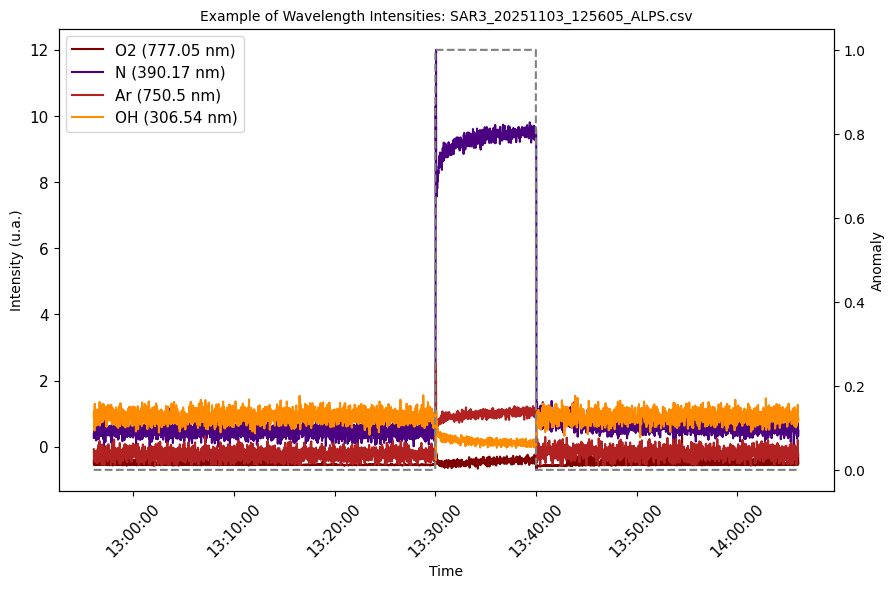

In [384]:
try:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot 'O2' for Wavelength: 
    ax1.plot(result.CURRENTTIMESTAMP, result[o_wavelength], color=o_color, label=f"O2 ({o_wavelength} nm)")
    
    # Plot 'N' for Wavelength: 
    ax1.plot(result.CURRENTTIMESTAMP, result[n_wavelength], color=n_color, label=f"N ({n_wavelength} nm)")

    # Plot 'Ar' for Wavelength: 
    ax1.plot(result.CURRENTTIMESTAMP, result[a_wavelength], color=a_color, label=f"Ar ({a_wavelength} nm)")

    # Plot 'OH' for Wavelength: 
    ax1.plot(result.CURRENTTIMESTAMP, result[oh_wavelength], color=oh_color, label=f"OH ({oh_wavelength} nm)")



    ax1.set_xlabel('Time', fontsize=FONTSIZE_SEC)
    ax1.set_ylabel('Intensity (u.a.)', fontsize=FONTSIZE_SEC)
    ax1.set_title('Example of Wavelength Intensities: '+ NAME_FILE, fontsize=FONTSIZE_SEC)
    ax1.legend(loc='upper left', fontsize=FONTSIZE_MAIN)

    ax1.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
    ax1.tick_params(axis='y', labelsize=FONTSIZE_MAIN)

    # Format x-axis for hours, minutes, and seconds
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    # Second y-axis for Ground Truth
    ax2 = ax1.twinx()
    try:

        ax2.plot(result.CURRENTTIMESTAMP, result["ANOMALY?"], color="Grey", linestyle="dashed", label="Ground Truth")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)

    except:
        print("No Ground Truth available")

    
    """
    try:
        # Second y-axis for Ground Truth
        ax2 = ax1.twinx()
        #ax2.plot(result.CURRENTTIMESTAMP, result["ETATREALTIMELIFE"], color="Grey", linestyle="dashed", label="ETATREALTIMELIFE")
        ax2.set_ylabel('Anomaly', fontsize=FONTSIZE_SEC)
        ax2.legend(loc='upper right', fontsize=FONTSIZE_MAIN)

        ax2.tick_params(axis='x', labelsize=FONTSIZE_MAIN)
        ax2.tick_params(axis='y', labelsize=FONTSIZE_MAIN)
    except:
        print("No ETATREALTIMELIFE available")
    
    plt.show()
    """

except Exception as e:
    print("Error plotting specific wavelengths", e)
